In [26]:
!pip install selenium

In [2]:
from selenium import webdriver

In [19]:
driver = webdriver.Chrome()
driver.get("https://www.naver.com")

In [20]:
driver.quit()

## 2. 셀프 주요소가 정말 저렴할까? - 데이터 확보하기 위한 작업
 - https://www.opinet.co.kr/searRgSelect.do
 - 사이트 구조 확인
 - 목표 데이터
 
    - 브랜드
    - 가격
    - 셀프 주유 여부    
    - 위치

## 3. 셀레니움으로 접근

In [34]:
from selenium import webdriver
from selenium.webdriver.common.by import By

In [4]:
url = "https://www.opinet.co.kr/searRgSelect.do"
driver = webdriver.Chrome()
driver.get(url)

 - 문제
    - 해당 주소로 한 번에 접근 안됨(지금은 되는듯?)
    - 메인페이지로 접속되고, 팝업창 뜸

In [39]:
# 지역: 시/도

sido_list_raw = driver.find_element(By.ID,"SIDO_NM0")
sido_list_raw.text

'            시/도\n            \n             \n             \n              서울\n             \n            \n             \n             \n              부산\n             \n            \n             \n             \n              대구\n             \n            \n             \n              인천\n             \n             \n            \n             \n             \n              광주\n             \n            \n             \n             \n              대전\n             \n            \n             \n             \n              울산\n             \n            \n             \n             \n              세종\n             \n            \n             \n             \n              경기\n             \n            \n             \n             \n              충북\n             \n            \n             \n             \n              충남\n             \n            \n             \n             \n              전북\n             \n            \n             \n             \n              

In [47]:
sido_list = sido_list_raw.find_elements(By.TAG_NAME, 'option')
len(sido_list), sido_list[17].text

(18, '강원')

In [48]:
sido_list[1].get_attribute("value")

'서울특별시'

In [96]:
sido_names = []

for option in sido_list:
    sido_names.append(option.get_attribute("value"))   
sido_names

['',
 '서울특별시',
 '부산광역시',
 '대구광역시',
 '인천광역시',
 '광주광역시',
 '대전광역시',
 '울산광역시',
 '세종특별자치시',
 '경기도',
 '충청북도',
 '충청남도',
 '전라북도',
 '전라남도',
 '경상북도',
 '경상남도',
 '제주특별자치도',
 '강원특별자치도']

In [97]:
sido_names = sido_names[1:]
sido_names

['서울특별시',
 '부산광역시',
 '대구광역시',
 '인천광역시',
 '광주광역시',
 '대전광역시',
 '울산광역시',
 '세종특별자치시',
 '경기도',
 '충청북도',
 '충청남도',
 '전라북도',
 '전라남도',
 '경상북도',
 '경상남도',
 '제주특별자치도',
 '강원특별자치도']

In [98]:
sido_names

['서울특별시',
 '부산광역시',
 '대구광역시',
 '인천광역시',
 '광주광역시',
 '대전광역시',
 '울산광역시',
 '세종특별자치시',
 '경기도',
 '충청북도',
 '충청남도',
 '전라북도',
 '전라남도',
 '경상북도',
 '경상남도',
 '제주특별자치도',
 '강원특별자치도']

In [104]:
sido_list_raw.send_keys(sido_names[5])

In [114]:
# 구

gu_list_raw = driver.find_element(By.ID, "SIGUNGU_NM0") #부모 태그
gu_list = gu_list_raw.find_elements(By.TAG_NAME, 'option')

gu_names = [option.get_attribute("value") for option in gu_list]
gu_names = gu_names[1:]
gu_names

['강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구']

In [115]:
gu_list_raw.send_keys(gu_names[10])

In [117]:
#엑셀 저장

driver.find_element(By.ID,"glopopd_excel").click()

In [122]:
import time
from tqdm import tqdm_notebook

for gu in tqdm_notebook(gu_names):
    element = driver.find_element(By.ID, "SIGUNGU_NM0")
    element.send_keys(gu)
    time.sleep(3)
    
    element_get_excel = driver.find_element(By.ID,"glopopd_excel").click()
    time.sleep(2)

C:\Users\shchoi\AppData\Local\Temp\ipykernel_1824\2572269791.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for gu in tqdm_notebook(gu_names):


  0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [124]:
driver.close()

InvalidSessionIdException: Message: invalid session id
Stacktrace:
	GetHandleVerifier [0x00007FF65B328EF2+54786]
	(No symbol) [0x00007FF65B295612]
	(No symbol) [0x00007FF65B14A4FD]
	(No symbol) [0x00007FF65B18038E]
	(No symbol) [0x00007FF65B1ABD62]
	(No symbol) [0x00007FF65B1A7AD0]
	(No symbol) [0x00007FF65B1A73D6]
	(No symbol) [0x00007FF65B120CD0]
	GetHandleVerifier [0x00007FF65B677F52+3524194]
	GetHandleVerifier [0x00007FF65B6CD800+3874576]
	GetHandleVerifier [0x00007FF65B6C5D7F+3843215]
	GetHandleVerifier [0x00007FF65B3C5086+694166]
	(No symbol) [0x00007FF65B2A0A88]
	(No symbol) [0x00007FF65B11FAFE]
	GetHandleVerifier [0x00007FF65B70F1E8+4143352]
	BaseThreadInitThunk [0x00007FFFB79E7344+20]
	RtlUserThreadStart [0x00007FFFB7E426B1+33]


In [126]:
import pandas as pd
from glob import glob

In [185]:
#파일 목록 한번에 가져오기
glob("./data/지역_*.xls")

['./data\\지역_위치별(주유소) (1).xls',
 './data\\지역_위치별(주유소) (10).xls',
 './data\\지역_위치별(주유소) (11).xls',
 './data\\지역_위치별(주유소) (12).xls',
 './data\\지역_위치별(주유소) (13).xls',
 './data\\지역_위치별(주유소) (14).xls',
 './data\\지역_위치별(주유소) (15).xls',
 './data\\지역_위치별(주유소) (16).xls',
 './data\\지역_위치별(주유소) (17).xls',
 './data\\지역_위치별(주유소) (18).xls',
 './data\\지역_위치별(주유소) (19).xls',
 './data\\지역_위치별(주유소) (2).xls',
 './data\\지역_위치별(주유소) (20).xls',
 './data\\지역_위치별(주유소) (21).xls',
 './data\\지역_위치별(주유소) (22).xls',
 './data\\지역_위치별(주유소) (23).xls',
 './data\\지역_위치별(주유소) (24).xls',
 './data\\지역_위치별(주유소) (25).xls',
 './data\\지역_위치별(주유소) (3).xls',
 './data\\지역_위치별(주유소) (4).xls',
 './data\\지역_위치별(주유소) (5).xls',
 './data\\지역_위치별(주유소) (6).xls',
 './data\\지역_위치별(주유소) (7).xls',
 './data\\지역_위치별(주유소) (8).xls',
 './data\\지역_위치별(주유소) (9).xls']

In [186]:
#파일명 저장
stations_files = glob("./data/지역_*.xls")
stations_files[:5]

['./data\\지역_위치별(주유소) (1).xls',
 './data\\지역_위치별(주유소) (10).xls',
 './data\\지역_위치별(주유소) (11).xls',
 './data\\지역_위치별(주유소) (12).xls',
 './data\\지역_위치별(주유소) (13).xls']

In [187]:
#하나만 읽어보기
tmp = pd.read_excel(stations_files[5], header=2)
tmp.tail()

,지역,상호,주소,상표,전화번호,셀프여부,고급휘발유,휘발유,경유,실내등유
10,서울특별시,(주)가재울뉴타운주유소,서울 서대문구 모래내로 205,HD현대오일뱅크,070-8879-7864,Y,-,1792,1692,-
11,서울특별시,삼미상사(주)서부주유소,서울 서대문구 성산로 255,SK에너지,02-334-4919,Y,-,1795,1695,-
12,서울특별시,행촌제2주유소,서울 서대문구 성산로 490 (대신동),SK에너지,02-365-5189,Y,1978,1795,1695,-
13,서울특별시,연희주유소,서울 서대문구 연희로 129 (연희동 89-7번지),SK에너지,02-338-8045,N,2088,1798,1728,-
14,서울특별시,광호주유소,서울 서대문구 연희로 266 (홍은동),SK에너지,02-395-7236,N,-,1798,1728,-


In [188]:
tmp_raw = []

for file_name in stations_files:
    tmp = pd.read_excel(file_name, header=2)
    tmp_raw.append(tmp)

In [140]:
tmp_raw

[       지역                   상호                         주소        상표  \
 0   서울특별시                방죽주유소      서울 강남구 밤고개로 215 (율현동)     GS칼텍스   
 1   서울특별시          (주)보성 세곡주유소      서울 강남구  헌릉로 731 (세곡동)     SK에너지   
 2   서울특별시               삼성동주유소      서울 강남구 테헤란로 619 (삼성동)  HD현대오일뱅크   
 3   서울특별시             오일프러스 셀프    서울 강남구 남부순환로 2651 (도곡동)     SK에너지   
 4   서울특별시  HD현대오일뱅크㈜직영 도곡셀프주유소  서울 강남구  남부순환로 2718 (도곡2동)  HD현대오일뱅크   
 5   서울특별시         극동유화㈜ 개나리주유소       서울 강남구 언주로 423 (역삼동)     S-OIL   
 6   서울특별시       (주)중앙에너비스 수서지점       서울 강남구 광평로 202 (수서동)     SK에너지   
 7   서울특별시  HD현대오일뱅크㈜직영 산성셀프주유소             서울 강남구 헌릉로 730  HD현대오일뱅크   
 8   서울특별시              자곡셀프주유소      서울 강남구 밤고개로 120 (자곡동)     SK에너지   
 9   서울특별시    HD현대오일뱅크㈜직영 유진주유소       서울 강남구 논현로 152 (도곡동)  HD현대오일뱅크   
 10  서울특별시              SK서광주유소             서울 강남구 역삼로 142     SK에너지   
 11  서울특별시  지에스칼텍스㈜에너지플러스허브GS타워       서울 강남구 논현로 516 (역삼동)     GS칼텍스   
 12  서울특별시        SK에너지㈜ 진달래주유소             서울 강남구 도곡로 208     S

* 형식이 동일하고 연달아 붙이기만 하면 될 때는 concat

In [189]:
station_raw = pd.concat(tmp_raw)
station_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 436 entries, 0 to 13
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      436 non-null    object
 1   상호      436 non-null    object
 2   주소      436 non-null    object
 3   상표      436 non-null    object
 4   전화번호    436 non-null    object
 5   셀프여부    436 non-null    object
 6   고급휘발유   436 non-null    object
 7   휘발유     436 non-null    object
 8   경유      436 non-null    object
 9   실내등유    436 non-null    object
dtypes: object(10)
memory usage: 37.5+ KB


In [190]:
stations = pd.DataFrame({"상호":station_raw['상호'],
                        "주소":station_raw['주소'],
                         "휘발유가격":station_raw['휘발유'],
                         "셀프":station_raw['셀프여부'],
                         '상표':station_raw['상표'],
                         })
stations.tail()

,상호,주소,휘발유가격,셀프,상표
9,상계동주유소,서울 노원구 노원로26길 191 (상계동),1795,N,HD현대오일뱅크
10,(주)소모 수락산셀프주유소,서울 노원구 동일로 1772,1797,Y,GS칼텍스
11,신성주유소,서울 노원구 월계로 328 (월계동),1798,Y,S-OIL
12,SK에너지㈜직영 상계주유소,서울 노원구 노해로 527 (상계동),1799,N,SK에너지
13,하계삼호주유소,서울 노원구 공릉로 294 (하계동),1900,N,GS칼텍스


In [191]:
for eachadd in stations['주소']:
    print(eachadd.split()[1]) #구만 뽑아내기

강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
강남구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
도봉구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동대문구
동작구
동작구
동작구
동작구
동작구
동작구
동작구
동작구
동작구
마포구
마포구
마포구
마포구
마포구
마포구
마포구
마포구
마포구
마포구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서대문구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
서초구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성동구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
성북구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
송파구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
양천구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
강동구
영등포구
영등포구
영등포구
영등포구
영등포구
영등포구
영

In [192]:
stations['구'] = [eachadd.split()[1] for eachadd in stations['주소']]
stations

,상호,주소,휘발유가격,셀프,상표,구
0,방죽주유소,서울 강남구 밤고개로 215 (율현동),1757,Y,GS칼텍스,강남구
1,(주)보성 세곡주유소,서울 강남구 헌릉로 731 (세곡동),1768,Y,SK에너지,강남구
2,삼성동주유소,서울 강남구 테헤란로 619 (삼성동),1775,Y,HD현대오일뱅크,강남구
3,오일프러스 셀프,서울 강남구 남부순환로 2651 (도곡동),1784,Y,SK에너지,강남구
4,HD현대오일뱅크㈜직영 도곡셀프주유소,서울 강남구 남부순환로 2718 (도곡2동),1784,Y,HD현대오일뱅크,강남구
...,...,...,...,...,...,...
9,상계동주유소,서울 노원구 노원로26길 191 (상계동),1795,N,HD현대오일뱅크,노원구
10,(주)소모 수락산셀프주유소,서울 노원구 동일로 1772,1797,Y,GS칼텍스,노원구
11,신성주유소,서울 노원구 월계로 328 (월계동),1798,Y,S-OIL,노원구
12,SK에너지㈜직영 상계주유소,서울 노원구 노해로 527 (상계동),1799,N,SK에너지,노원구


In [193]:
len(stations['구'].unique()), stations['구'].unique()

(25,
 array(['강남구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구',
        '송파구', '양천구', '강동구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구',
        '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구'], dtype=object))

In [196]:
# 가격 데이터 변환 object -> float
# 가격 정보 없는 주유소 제외 후 변환
stations[stations['휘발유가격'] == "-"]
stations = stations[stations['휘발유가격'] != "-"]
stations

,상호,주소,휘발유가격,셀프,상표,구
0,방죽주유소,서울 강남구 밤고개로 215 (율현동),1757,Y,GS칼텍스,강남구
1,(주)보성 세곡주유소,서울 강남구 헌릉로 731 (세곡동),1768,Y,SK에너지,강남구
2,삼성동주유소,서울 강남구 테헤란로 619 (삼성동),1775,Y,HD현대오일뱅크,강남구
3,오일프러스 셀프,서울 강남구 남부순환로 2651 (도곡동),1784,Y,SK에너지,강남구
4,HD현대오일뱅크㈜직영 도곡셀프주유소,서울 강남구 남부순환로 2718 (도곡2동),1784,Y,HD현대오일뱅크,강남구
...,...,...,...,...,...,...
9,상계동주유소,서울 노원구 노원로26길 191 (상계동),1795,N,HD현대오일뱅크,노원구
10,(주)소모 수락산셀프주유소,서울 노원구 동일로 1772,1797,Y,GS칼텍스,노원구
11,신성주유소,서울 노원구 월계로 328 (월계동),1798,Y,S-OIL,노원구
12,SK에너지㈜직영 상계주유소,서울 노원구 노해로 527 (상계동),1799,N,SK에너지,노원구


In [197]:
stations['휘발유가격'] = stations['휘발유가격'].astype('float')
stations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 435 entries, 0 to 13
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상호      435 non-null    object 
 1   주소      435 non-null    object 
 2   휘발유가격   435 non-null    float64
 3   셀프      435 non-null    object 
 4   상표      435 non-null    object 
 5   구       435 non-null    object 
dtypes: float64(1), object(5)
memory usage: 23.8+ KB


In [199]:
stations.reset_index(inplace=True)
stations.head()

,level_0,index,상호,주소,휘발유가격,셀프,상표,구
0,0,0,방죽주유소,서울 강남구 밤고개로 215 (율현동),1757.0,Y,GS칼텍스,강남구
1,1,1,(주)보성 세곡주유소,서울 강남구 헌릉로 731 (세곡동),1768.0,Y,SK에너지,강남구
2,2,2,삼성동주유소,서울 강남구 테헤란로 619 (삼성동),1775.0,Y,HD현대오일뱅크,강남구
3,3,3,오일프러스 셀프,서울 강남구 남부순환로 2651 (도곡동),1784.0,Y,SK에너지,강남구
4,4,4,HD현대오일뱅크㈜직영 도곡셀프주유소,서울 강남구 남부순환로 2718 (도곡2동),1784.0,Y,HD현대오일뱅크,강남구


In [204]:
#del stations['level_0']
#del stations['index']

In [206]:
stations

,상호,주소,휘발유가격,셀프,상표,구
0,방죽주유소,서울 강남구 밤고개로 215 (율현동),1757.0,Y,GS칼텍스,강남구
1,(주)보성 세곡주유소,서울 강남구 헌릉로 731 (세곡동),1768.0,Y,SK에너지,강남구
2,삼성동주유소,서울 강남구 테헤란로 619 (삼성동),1775.0,Y,HD현대오일뱅크,강남구
3,오일프러스 셀프,서울 강남구 남부순환로 2651 (도곡동),1784.0,Y,SK에너지,강남구
4,HD현대오일뱅크㈜직영 도곡셀프주유소,서울 강남구 남부순환로 2718 (도곡2동),1784.0,Y,HD현대오일뱅크,강남구
...,...,...,...,...,...,...
430,상계동주유소,서울 노원구 노원로26길 191 (상계동),1795.0,N,HD현대오일뱅크,노원구
431,(주)소모 수락산셀프주유소,서울 노원구 동일로 1772,1797.0,Y,GS칼텍스,노원구
432,신성주유소,서울 노원구 월계로 328 (월계동),1798.0,Y,S-OIL,노원구
433,SK에너지㈜직영 상계주유소,서울 노원구 노해로 527 (상계동),1799.0,N,SK에너지,노원구


In [213]:
!pip install seaborn

   ---------------------------------------- 0.0/294.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.6 kB ? eta -:--:--
   ----- --------------------------------- 41.0/294.6 kB 393.8 kB/s eta 0:00:01
   ---------------------------------------- 294.6/294.6 kB 2.0 MB/s eta 0:00:00


In [224]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from matplotlib import font_manager, rc
%matplotlib inline

get_ipython().run_line_magic("matplotlib", 'inline')

path = "C:/Windows/Fonts/malgun.ttf"

if platform.system() == 'Windows':
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Linux':
    rc('font', family='NanumBarunGothic')
else:
    print('Unknown system... sorry~~~~~~')

<Axes: title={'center': '휘발유가격'}, xlabel='셀프'>

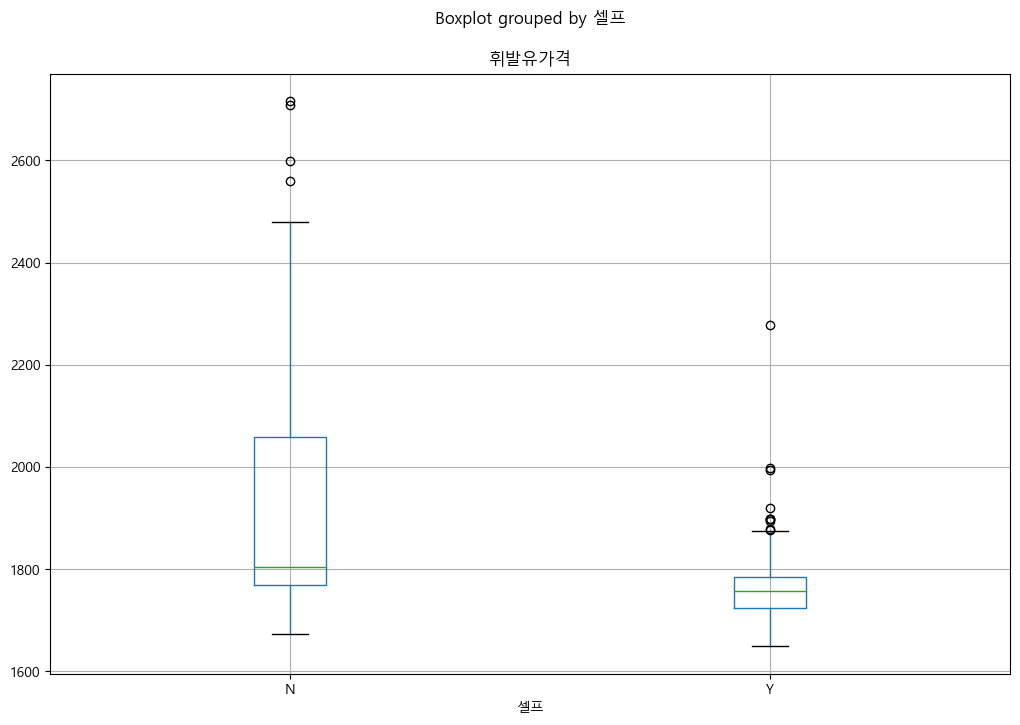

In [226]:
#boxplot (판다스)

stations.boxplot(column='휘발유가격', by='셀프', figsize=(12,8))

C:\Users\shchoi\AppData\Local\Temp\ipykernel_1824\2493959032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='셀프', y='휘발유가격', data = stations, palette='Set2')


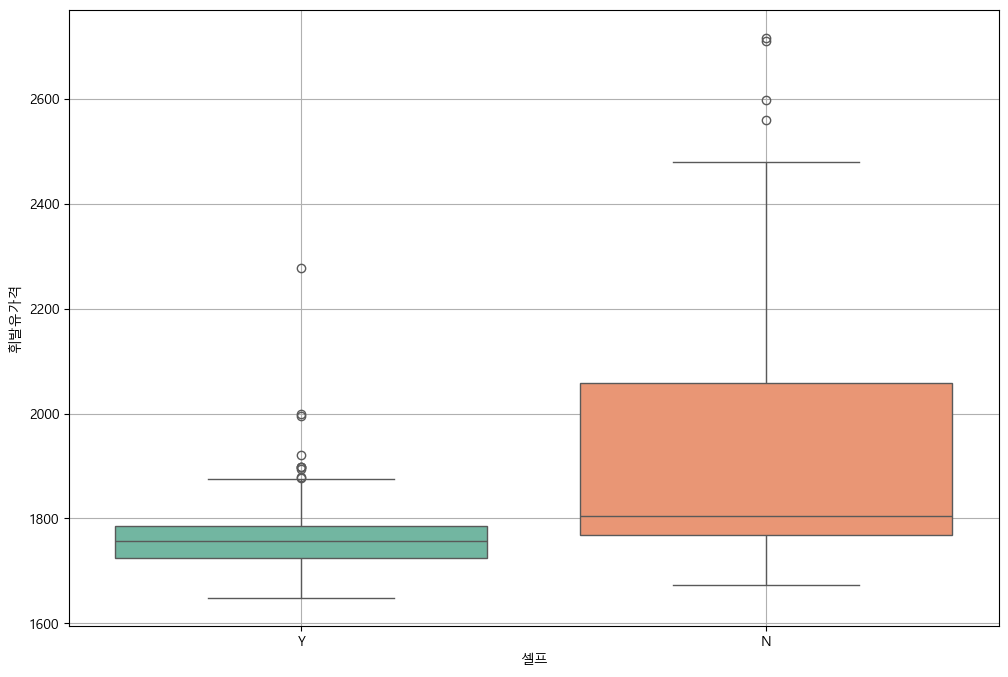

In [233]:
#boxplot (seaborn)

plt.figure(figsize=(12,8))
sns.boxplot(x='셀프', y='휘발유가격', data = stations, palette='Set2')
plt.grid()
plt.show()

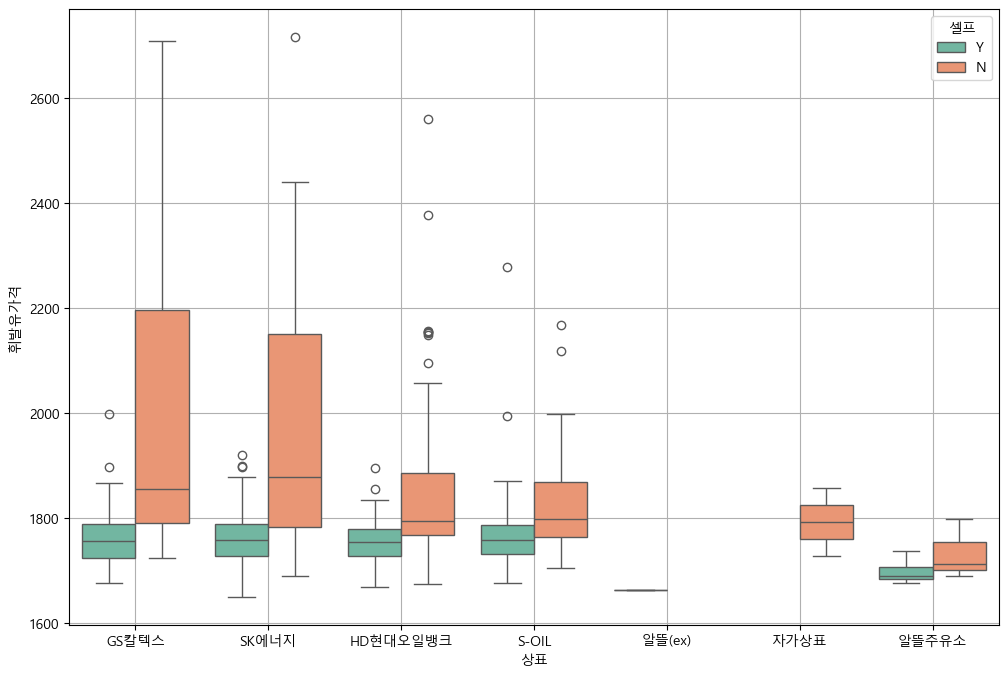

In [236]:
#boxplot (seaborn)

plt.figure(figsize=(12,8))
sns.boxplot(x='상표', y='휘발유가격', data = stations, palette='Set2', hue='셀프')
plt.grid()
plt.show()

In [237]:
#지도 시각화


In [243]:
import json
import folium
import warnings
import numpy as np
warnings.simplefilter(action='ignore', category=FutureWarning)

In [240]:
#가장 비싼 주유소 10개
stations.sort_values(by='휘발유가격', ascending=False).head(10)

,상호,주소,휘발유가격,셀프,상표,구
305,서남주유소,서울 중구 통일로 30,2716.0,N,SK에너지,중구
271,서계주유소,서울 용산구 청파로 367 (청파동),2709.0,N,GS칼텍스,용산구
30,(주)만정에너지 삼보주유소,서울 강남구 봉은사로 433 (삼성동),2598.0,N,GS칼텍스,강남구
29,(주)제이제이네트웍스 제이제이주유소,서울 강남구 언주로 716,2560.0,N,HD현대오일뱅크,강남구
304,필동주유소,서울 중구 퇴계로 196 (필동2가),2479.0,N,GS칼텍스,중구
303,약수주유소,서울 중구 다산로 173,2448.0,N,GS칼텍스,중구
28,SK논현주유소,서울 강남구 논현로 747 (논현동),2440.0,N,SK에너지,강남구
295,(주)대양씨앤씨 사직주유소,서울 종로구 사직로 65 (사직동),2390.0,N,GS칼텍스,종로구
27,㈜새서울석유 새서울주유소,서울 강남구 압구정로 154,2378.0,N,HD현대오일뱅크,강남구
294,경복궁주유소,서울 종로구 율곡로 6 (중학동),2370.0,N,GS칼텍스,종로구


In [241]:
#가장 싼 주유소 10개
stations.sort_values(by='휘발유가격', ascending=True).head(10)

,상호,주소,휘발유가격,셀프,상표,구
331,강서오곡셀프주유소,서울 강서구 벌말로 254 (오곡동),1649.0,Y,SK에너지,강서구
99,만남의광장주유소,서울 서초구 양재대로12길 73-71,1664.0,Y,알뜰(ex),서초구
390,(주)서울에너지 궁동주유소,서울 구로구 오리로 1299 (궁동),1669.0,Y,HD현대오일뱅크,구로구
391,서서울고속주유소,서울 구로구 경인로 150 (오류동),1669.0,Y,SK에너지,구로구
272,(주)디오티디 은평유니콘주유소,서울 은평구 통일로 1151 (진관동),1674.0,N,HD현대오일뱅크,은평구
235,영등포현대셀프주유소,서울 영등포구 경인로 822 (영등포동),1677.0,Y,HD현대오일뱅크,영등포구
234,(주)강서오일,서울 영등포구 도신로 151,1677.0,Y,HD현대오일뱅크,영등포구
233,남서울고속주유소,서울 영등포구 가마산로 367 (대림동),1677.0,Y,SK에너지,영등포구
238,한경석유(주)경덕주유소,서울 영등포구 여의대방로23길 2 (신길동),1677.0,Y,SK에너지,영등포구
239,도림주유소,서울 영등포구 도림로 343 (도림동),1677.0,Y,알뜰주유소,영등포구


In [247]:
gu_data = pd.pivot_table(stations, index='구', values='휘발유가격', aggfunc=np.mean)
gu_data.head()

,휘발유가격
구,
강남구,2007.096774
강동구,1880.846154
강북구,1729.916667
강서구,1774.030303
관악구,1789.785714


In [248]:
geo_path = ""

NameError: name 'geo' is not defined